<a href="https://colab.research.google.com/github/WickedSero/_CDV_MachineLearning/blob/main/ML_zadanie_7_grupowanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Wczytaj niezbędne biblioteki

In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

## Wstępna obróbka danych

### Wczytaj dane, zapoznaj się z nimi i je oczyść

In [ ]:
# Wczytaj plik, separator to średnik, pierwsza kolumna to id
data = pd.read_csv('/content/dania.rybne.csv', sep=';')
features = data.iloc[:, 1:]

# Wyświetl kilka pierwszych wierszy dla weryfikacji
print(data.head())

# Wyświetl informacje o DF
data.info()

   id  V1  V2  V3  V4  V5  V6  V7  V8  V9  V10  V11  V12  V13
0   5   5   1   4   2   3   4   3   1   3    2    4    4    3
1   8   4   1   1   5   1   4   4   3   5    1    5    3    2
2  15   2   1   1   1   1   1   2   2   1    2    1    1    2
3  17   4   3   4   4   4   4   4   4   4    4    4    4    3
4  18   4   2   3   3   4   3   2   2   4    4    5    4    3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1000 non-null   int64
 1   V1      1000 non-null   int64
 2   V2      1000 non-null   int64
 3   V3      1000 non-null   int64
 4   V4      1000 non-null   int64
 5   V5      1000 non-null   int64
 6   V6      1000 non-null   int64
 7   V7      1000 non-null   int64
 8   V8      1000 non-null   int64
 9   V9      1000 non-null   int64
 10  V10     1000 non-null   int64
 11  V11     1000 non-null   int64
 12  V12     1000 non-null   int

In [ ]:
# Wyświetlanie unikalnych wartości dla każdej kolumny oprócz 'id'
for column in data.columns:
    if column != 'id':
        unique_values = data[column].unique()
        print(f"Kolumna '{column}': {unique_values}")

Kolumna 'V1': [5 4 2 3 1]
Kolumna 'V2': [1 3 2 4 5]
Kolumna 'V3': [4 1 3 2 5]
Kolumna 'V4': [2 5 1 4 3]
Kolumna 'V5': [3 1 4 2 5]
Kolumna 'V6': [4 1 3 5 2]
Kolumna 'V7': [3 4 2 5 1]
Kolumna 'V8': [1 3 2 4 5]
Kolumna 'V9': [3 5 1 4 2]
Kolumna 'V10': [2 1 4 5 3]
Kolumna 'V11': [4 5 1 2 3]
Kolumna 'V12': [4 3 1 5 2]
Kolumna 'V13': [3 2 5 4 1]


## Grupowanie hierarchiczne

### Dobór metody mierzenia odległości i grupowania

Każda z kolumn ma 5 stopniową skalę w zakresie 1-5.

Mamy zatem skalę porządkową ze zmiennymi dyskretnymi. Wobec tego, uzasadnionym wydaje się użycie metody pomiaru odgległości Manhattan (Cityblock) oraz grupowanie metodą Warda.


In [ ]:
print(features.head())

   V1  V2  V3  V4  V5  V6  V7  V8  V9  V10  V11  V12  V13
0   5   1   4   2   3   4   3   1   3    2    4    4    3
1   4   1   1   5   1   4   4   3   5    1    5    3    2
2   2   1   1   1   1   1   2   2   1    2    1    1    2
3   4   3   4   4   4   4   4   4   4    4    4    4    3
4   4   2   3   3   4   3   2   2   4    4    5    4    3


In [ ]:
# Obliczanie odległości Manhattan
distance_matrix = pdist(features, metric='cityblock')
linkage_matrix = linkage(distance_matrix, method='ward')

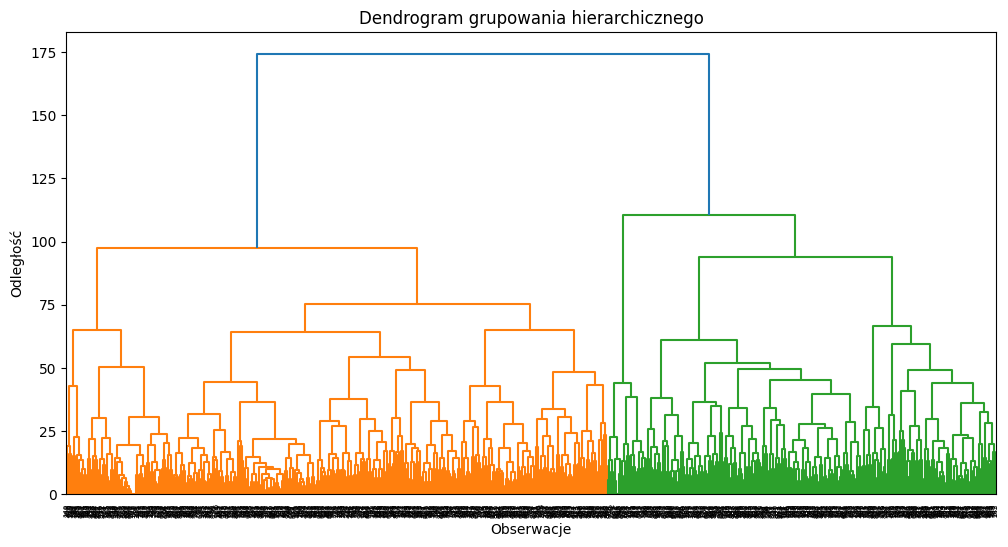

In [ ]:
# Wizualizacja dendrogramu
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Dendrogram grupowania hierarchicznego")
plt.xlabel("Obserwacje")
plt.ylabel("Odległość")
plt.show()

### Zbuduj 5 modeli o różnej liczbie skupień.

In [ ]:
results = {}
for n_clusters in range(2, 7):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(features)
    results[n_clusters] = labels

### Przedstaw wyniki w jednej ramce danych.

In [ ]:
clusters_df = features.copy()
for n_clusters, labels in results.items():
    clusters_df[f'Cluster_{n_clusters}'] = labels

print("Fragment ramki danych:")
print(clusters_df.head())


Fragment ramki danych:
   V1  V2  V3  V4  V5  V6  V7  V8  V9  V10  V11  V12  V13  Cluster_2  \
0   5   1   4   2   3   4   3   1   3    2    4    4    3          0   
1   4   1   1   5   1   4   4   3   5    1    5    3    2          1   
2   2   1   1   1   1   1   2   2   1    2    1    1    2          1   
3   4   3   4   4   4   4   4   4   4    4    4    4    3          0   
4   4   2   3   3   4   3   2   2   4    4    5    4    3          0   

   Cluster_3  Cluster_4  Cluster_5  Cluster_6  
0          1          0          1          0  
1          0          3          3          3  
2          0          1          0          5  
3          1          0          4          1  
4          1          0          4          1  


### Zilustruj wyniki na wykresach.

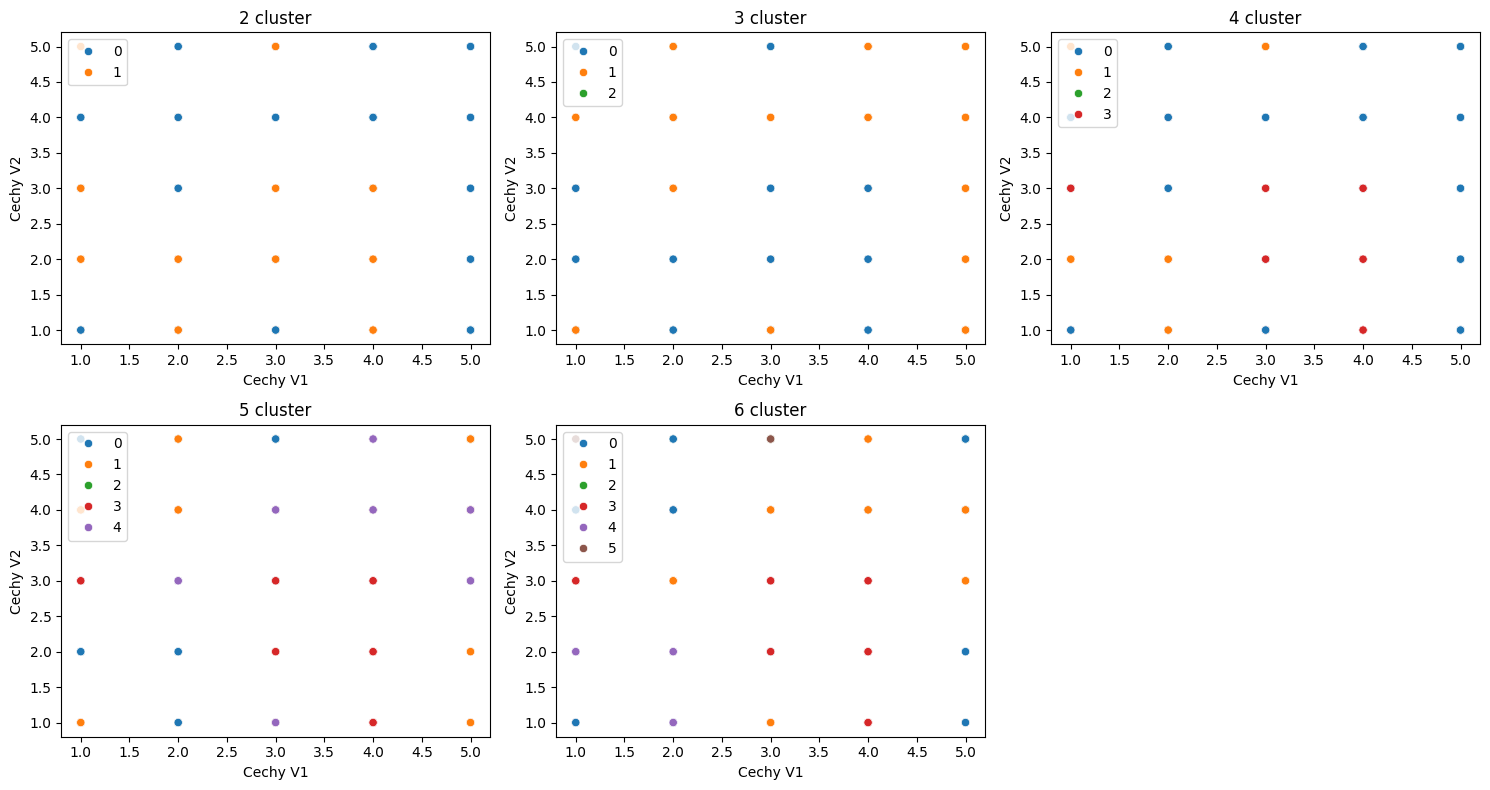

In [ ]:
#Wizualizacja na wykresach (dla 2 głównych cech)
plt.figure(figsize=(15, 8))
for i, n_clusters in enumerate(range(2, 7), 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(
        x=features.iloc[:, 0],
        y=features.iloc[:, 1],
        hue=results[n_clusters],
        palette='tab10'
    )
    plt.title(f"{n_clusters} cluster")
    plt.xlabel("Cechy V1")
    plt.ylabel("Cechy V2")
plt.tight_layout()
plt.show()

### Porównanie i interpretacja wyników

### Zastosuj dowolną metodę klasyfikacji, aby przypisać obserwacje do segmentów w każdym modelu.  

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, clusters_df['Cluster_3'], test_size=0.3, random_state=42
)

In [ ]:
# Trenowanie klasyfikatora
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Predykcja i ocena wyników
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Dokładność klasyfikacji dla 3 klastrów:", accuracy)

Dokładność klasyfikacji dla 3 klastrów: 0.8066666666666666


### Analiza klastrów

W zależności od liczby skupień (Cluster_2 do Cluster_6), widzimy różne struktury podziału danych:

* **2 klastry:** Najbardziej ogólny podział.
* **3 klastry:** Pojawia się grupa osób o neutralnym nastawieniu.
* **4-6 klastrów:** Można wyodrębnić bardziej precyzyjne preferencje.


### Interpretacja wyników klasyfikacji

Dokładność klasyfikacji dla 3 klastrów: 80.67%
Wysoka dokładność (80.67%) wskazuje, że model regresji logistycznej skutecznie przypisał obserwacje do trzech klastrów. To oznacza, że większość obserwacji w zestawie testowym została poprawnie sklasyfikowana do odpowiednich grup.

## Wykorzystaj grupowanie metodą k-średnich.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Załaduj dane
data = pd.read_csv('dania.rybne.csv', sep=';')

# Wybierz cechy do analizy (bez kolumny 'id')
features = data.iloc[:, 1:]

### Zbuduj modele o różnej liczbie skupień.

In [ ]:
# Słownik do przechowywania wyników
results = {}

# Budowanie modeli dla różnych liczby skupień
for n_clusters in range(2, 7):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(features)
    results[n_clusters] = labels

# Dodanie etykiet klastrów do oryginalnych danych
for n_clusters, labels in results.items():
    data[f'Cluster_{n_clusters}'] = labels

# Wyświetlenie pierwszych kilku wierszy z przypisanymi klastrami
print(data.head())

   id  V1  V2  V3  V4  V5  V6  V7  V8  V9  V10  V11  V12  V13  Cluster_2  \
0   5   5   1   4   2   3   4   3   1   3    2    4    4    3          0   
1   8   4   1   1   5   1   4   4   3   5    1    5    3    2          0   
2  15   2   1   1   1   1   1   2   2   1    2    1    1    2          0   
3  17   4   3   4   4   4   4   4   4   4    4    4    4    3          1   
4  18   4   2   3   3   4   3   2   2   4    4    5    4    3          1   

   Cluster_3  Cluster_4  Cluster_5  Cluster_6  
0          2          2          2          2  
1          1          1          1          1  
2          1          3          3          3  
3          0          0          4          4  
4          0          2          2          0  


### Wizualizujemy wyniki klasteryzacji na podstawie dwóch pierwszych cech (V1 i V2)

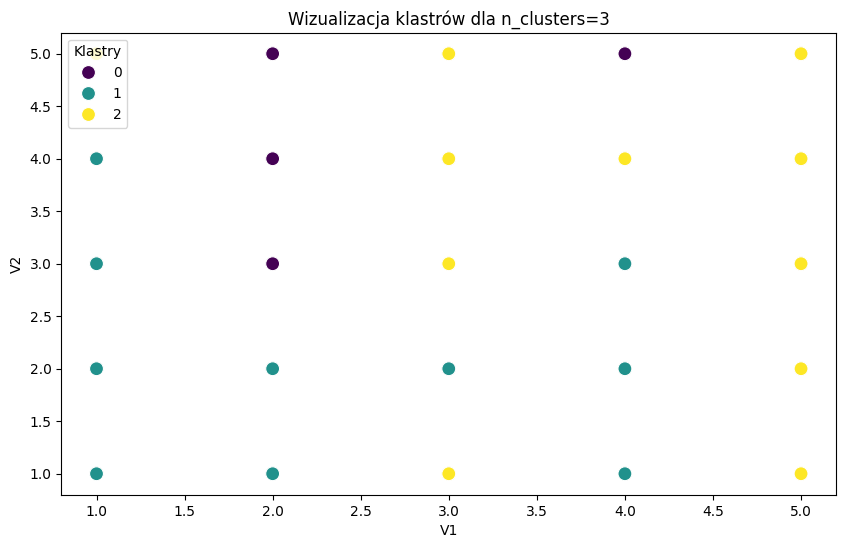

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['V1'], y=data['V2'], hue=data['Cluster_3'], palette='viridis', s=100
)
plt.title('Wizualizacja klastrów dla n_clusters=3')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend(title='Klastry')
plt.show()

### Zilustruj wyniki na wykresach.

Wykres Elbow
Metoda Elbow pozwala dobrać optymalną liczbę skupień na podstawie wartości sumy kwadratów odległości punktów od ich centroidów (inertia).

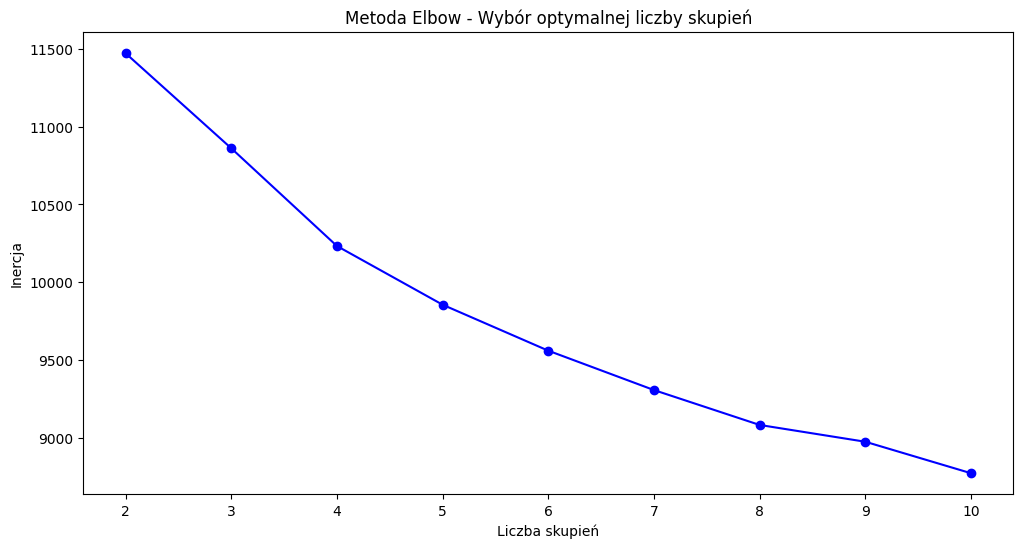

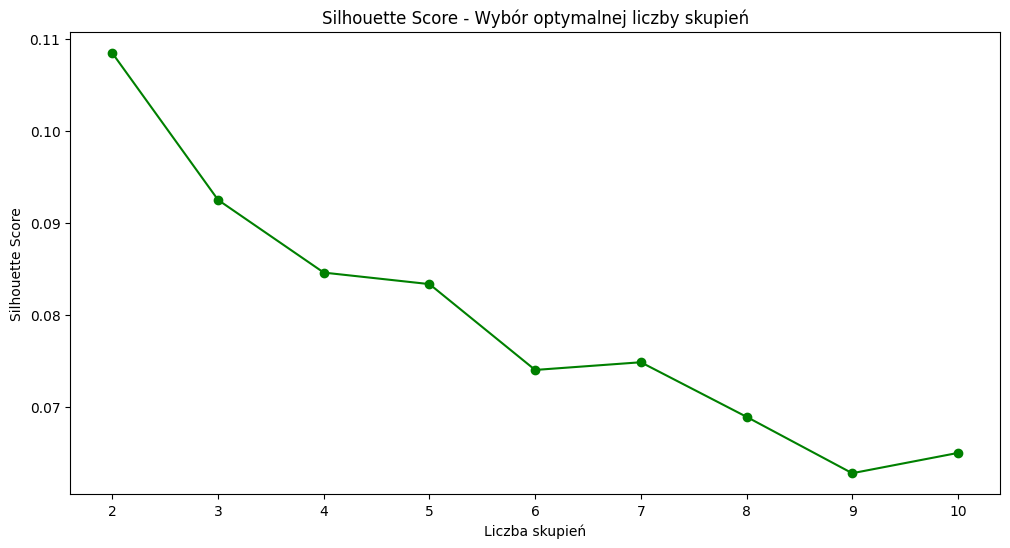

Optymalna liczba skupień na podstawie Silhouette Score: 2


In [ ]:
inertia = []
silhouette_scores = []

# Metoda Elbow i Silhouette
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(features_scaled)

    # Inercja (sumaryczna odległość punktów od centroidu)
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    silhouette = silhouette_score(features_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette)

# Wykres Elbow
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), inertia, marker='o', color='blue')
plt.title("Metoda Elbow - Wybór optymalnej liczby skupień")
plt.xlabel("Liczba skupień")
plt.ylabel("Inercja")
plt.show()

# Wykres Silhouette Score
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score - Wybór optymalnej liczby skupień")
plt.xlabel("Liczba skupień")
plt.ylabel("Silhouette Score")
plt.show()

# Optymalna liczba skupień z metod
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Optymalna liczba skupień na podstawie Silhouette Score: {optimal_clusters}")

Interpretacja wyników - Optymalna liczba skupień: 2
Na podstawie analizy Silhouette Score optymalna liczba skupień wynosi 2. Oznacza to, że model k-średnich z dwoma klastrami najlepiej oddziela obserwacje danych, zapewniając najwyższy wskaźnik jakości podziału.

Co to oznacza w praktyce?
Dwa skupienia sugerują, że dane są wyraźnie podzielone na dwie główne grupy. Możliwe, że są to osoby z wyraźnie różnymi preferencjami dotyczącymi gotowych dań rybnych.
Jedna grupa może preferować zdrowe dania rybne, a druga może być bardziej skłonna do wyboru dań typu fast-food.


Na podstawie przeprowadzonej analizy uważam, że najlepszym wyborem będzie dwuklasterowy model.
Uzasadnienie:
Prostota i interpretowalność: Dwuklasowy podział jest łatwy do zrozumienia i może odpowiadać na pytanie, jak podzielić osoby na dwie główne grupy w kontekście ich preferencji dotyczących gotowych dań rybnych.
Dobre rozdzielenie grup: Zgodnie z wynikiem Silhouette Score, model ten zapewnia dobrą separację pomiędzy grupami, co oznacza, że jest to najbardziej odpowiedni model do dalszej analizy.